In [2]:
import duckdb
import pandas as pd

conn = duckdb.connect('hubspot.db')

# Let pandas auto-detect encoding
#Change to your personal path to the csv files for this to work and read - you only do this once than you will have a local DB on ur machine and can SQl 
fs = pd.read_csv('/Users/Apple/Desktop/Hubspot/data/processed/frustration_signals_trimmed.csv', encoding_errors='replace') 
csat = pd.read_csv('/Users/Apple/Desktop/Hubspot/data/processed/csat.csv', encoding_errors='replace')
nps = pd.read_csv('/Users/Apple/Desktop/Hubspot/data/processed/nps.csv', encoding_errors='replace')
tickets = pd.read_csv('/Users/Apple/Desktop/Hubspot/data/processed/supportTickets.csv', encoding_errors='replace')

# Load into duckdb
conn.execute("CREATE TABLE IF NOT EXISTS frustration_signals AS SELECT * FROM fs")
conn.execute("CREATE TABLE IF NOT EXISTS csat AS SELECT * FROM csat")
conn.execute("CREATE TABLE IF NOT EXISTS nps AS SELECT * FROM nps")
conn.execute("CREATE TABLE IF NOT EXISTS support_tickets AS SELECT * FROM tickets")

conn.execute("SHOW TABLES").df()

,name
0,csat
1,frustration_signals
2,nps
3,support_tickets


In [3]:
#Column Names for all csvs
for table in ['csat', 'frustration_signals', 'nps', 'support_tickets']:
    print(f"\n--- {table} ---")
    print(conn.execute(f"DESCRIBE {table}").df()[['column_name', 'column_type']].to_string(index=False))


--- csat ---
     column_name column_type
            Date     VARCHAR
       Portal ID      DOUBLE
           Score      DOUBLE
     End User ID      DOUBLE
   Response Text     VARCHAR
Survey Name Sort      BIGINT
     Survey Name     VARCHAR
   Taxonomy Type     VARCHAR

--- frustration_signals ---
    column_name column_type
        COUNTRY     VARCHAR
     EVENT_TIME     VARCHAR
    SIGNAL_NAME     VARCHAR
DEPLOYABLE_NAME     VARCHAR
  PAGE_CATEGORY     VARCHAR

--- nps ---
    column_name column_type
    Response ID      BIGINT
           Date     VARCHAR
          Score      BIGINT
  Taxonomy Type     VARCHAR
  Response Text     VARCHAR
Translated Text     VARCHAR
       Page URL     VARCHAR

--- support_tickets ---
       column_name column_type
       History Key     VARCHAR
       Ticket Text     VARCHAR
          Language     VARCHAR
         Owner IDs     VARCHAR
       Ticket Name     VARCHAR
      Product Area     VARCHAR
         Roadblock     VARCHAR
        Resolution

In [16]:
# Signal distribution: understanding which frustration signals are most frequent
# This helps us identify the dominant frustration type and prioritize which signals to focus on
conn.execute("""
    SELECT SIGNAL_NAME, COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM frustration_signals
    GROUP BY SIGNAL_NAME
    ORDER BY count DESC
""").df()

,SIGNAL_NAME,count,percentage
0,"""Rage Click""",5775274,26.78
1,"""Repeated Navigation""",5677486,26.33
2,"""Text Highlighting""",5299550,24.58
3,"""Doom Scroll""",3478056,16.13
4,"""Dead Click""",1180772,5.48
5,"""Slow Keystrokes""",153507,0.71


In [17]:
# Page category analysis: identifying which areas of the product generate the most frustration
# This helps us pinpoint which product sections have the worst user experience
conn.execute("""
    SELECT PAGE_CATEGORY, COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM frustration_signals
    GROUP BY PAGE_CATEGORY
    ORDER BY count DESC
    LIMIT 20
""").df()

,PAGE_CATEGORY,count,percentage
0,contacts,5656892,26.23
1,live-messages,3674924,17.04
2,help-desk,3627544,16.82
3,unknown,3594104,16.67
4,reports-dashboard,1464185,6.79
5,pages,997089,4.62
6,prospecting,558195,2.59
7,email,459086,2.13
8,social,342414,1.59
9,reports-list,302004,1.40


In [18]:
# Deployable analysis: identifying which specific UI components or features trigger the most frustration
# This is more granular than page category and helps engineering teams know exactly what to fix
conn.execute("""
    SELECT DEPLOYABLE_NAME, COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM frustration_signals
    GROUP BY DEPLOYABLE_NAME
    ORDER BY count DESC
    LIMIT 20
""").df()

,DEPLOYABLE_NAME,count,percentage
0,"""crm-records-ui""",5057353,23.45
1,"""conversations-inbox-ui""",4612911,21.39
2,"""svh-help-desk""",4567811,21.18
3,"""DashboardUI""",1601714,7.43
4,"""crm-index-ui""",1313893,6.09
5,"""page-editor-ui""",1105170,5.12
6,"""prospecting-ui""",762758,3.54
7,"""SocialUI""",461270,2.14
8,"""quotes-admin-ui""",336942,1.56
9,"""reports-list""",328160,1.52


In [19]:
# Cross-tabulation: signal type by page category
# This reveals whether certain frustration types are concentrated in specific product areas
conn.execute("""
    SELECT PAGE_CATEGORY, SIGNAL_NAME, COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY PAGE_CATEGORY), 2) as pct_within_page
    FROM frustration_signals
    GROUP BY PAGE_CATEGORY, SIGNAL_NAME
    ORDER BY PAGE_CATEGORY, count DESC
""").df()

,PAGE_CATEGORY,SIGNAL_NAME,count,pct_within_page
0,academy,"""Text Highlighting""",12692,69.94
1,academy,"""Repeated Navigation""",5082,28.00
2,academy,"""Rage Click""",291,1.60
3,academy,"""Doom Scroll""",82,0.45
4,academy-navigation-components,"""Repeated Navigation""",368,98.92
...,...,...,...,...
402,user-guide,"""Text Highlighting""",802,1.23
403,user-guide,"""Slow Keystrokes""",5,0.01
404,user-invite-navigation-component,"""Rage Click""",53,63.10
405,user-invite-navigation-component,"""Text Highlighting""",30,35.71


In [20]:
# Cross-tabulation: signal type by deployable
# This tells us whether certain UI components trigger specific types of frustration
conn.execute("""
    SELECT DEPLOYABLE_NAME, SIGNAL_NAME, COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY DEPLOYABLE_NAME), 2) as pct_within_deployable
    FROM frustration_signals
    GROUP BY DEPLOYABLE_NAME, SIGNAL_NAME
    ORDER BY DEPLOYABLE_NAME, count DESC
    LIMIT 40
""").df()

,DEPLOYABLE_NAME,SIGNAL_NAME,count,pct_within_deployable
0,"""DashboardUI""","""Doom Scroll""",762464,47.60
1,"""DashboardUI""","""Rage Click""",580646,36.25
2,"""DashboardUI""","""Repeated Navigation""",217714,13.59
3,"""DashboardUI""","""Text Highlighting""",40082,2.50
4,"""DashboardUI""","""Slow Keystrokes""",808,0.05
5,"""EmailDragDropEditorUI""","""Rage Click""",184668,72.98
6,"""EmailDragDropEditorUI""","""Repeated Navigation""",60523,23.92
7,"""EmailDragDropEditorUI""","""Text Highlighting""",5464,2.16
8,"""EmailDragDropEditorUI""","""Doom Scroll""",1602,0.63
9,"""EmailDragDropEditorUI""","""Slow Keystrokes""",790,0.31


In [21]:
# Country analysis: identifying geographic patterns in frustration
# Helps determine if certain regions experience disproportionate frustration,
# which could indicate localization issues, latency problems, or regional UX gaps
conn.execute("""
    SELECT COUNTRY, COUNT(*) as total_signals,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct_of_total,
           COUNT(DISTINCT SIGNAL_NAME) as unique_signal_types
    FROM frustration_signals
    WHERE COUNTRY IS NOT NULL AND COUNTRY != 'None'
    GROUP BY COUNTRY
    ORDER BY total_signals DESC
    LIMIT 20
""").df()

,COUNTRY,total_signals,pct_of_total,unique_signal_types
0,United States,4731836,24.90,6
1,United Kingdom,1485225,7.82,6
2,Philippines,1342677,7.07,6
3,Brazil,1237218,6.51,6
4,India,810396,4.27,6
5,Germany,714620,3.76,6
6,Canada,643578,3.39,6
7,France,587590,3.09,6
8,Australia,587483,3.09,6
9,Colombia,583731,3.07,6


In [22]:
# Country x Signal cross-tab: understanding which frustration types are most prevalent per country
# Helps identify if certain regions have unique frustration patterns vs global trends
conn.execute("""
    SELECT COUNTRY, SIGNAL_NAME, COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY COUNTRY), 2) as pct_within_country
    FROM frustration_signals
    WHERE COUNTRY IS NOT NULL AND COUNTRY != 'None'
    GROUP BY COUNTRY, SIGNAL_NAME
    ORDER BY COUNTRY, count DESC
    LIMIT 40
""").df()

,COUNTRY,SIGNAL_NAME,count,pct_within_country
0,Afghanistan,"""Repeated Navigation""",51,55.43
1,Afghanistan,"""Rage Click""",21,22.83
2,Afghanistan,"""Text Highlighting""",11,11.96
3,Afghanistan,"""Doom Scroll""",9,9.78
4,Albania,"""Repeated Navigation""",1569,31.60
5,Albania,"""Text Highlighting""",1452,29.24
6,Albania,"""Rage Click""",938,18.89
7,Albania,"""Doom Scroll""",629,12.67
8,Albania,"""Dead Click""",370,7.45
9,Albania,"""Slow Keystrokes""",7,0.14


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Load a sample for correlation analysis - 21M rows is too large to load fully into memory
# We'll use a stratified sample that preserves the distribution of signal types
df = conn.execute("""
    SELECT COUNTRY, SIGNAL_NAME, DEPLOYABLE_NAME, PAGE_CATEGORY
    FROM frustration_signals
    WHERE COUNTRY IS NOT NULL AND COUNTRY != 'None'
    USING SAMPLE 500000
""").df()

print(df.shape)
df.head()

# Encode categorical variables numerically using label encoding
# Required for correlation analysis since all our variables are categorical
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()
df_encoded['COUNTRY_ENC'] = le.fit_transform(df['COUNTRY'])
df_encoded['SIGNAL_ENC'] = le.fit_transform(df['SIGNAL_NAME'])
df_encoded['DEPLOYABLE_ENC'] = le.fit_transform(df['DEPLOYABLE_NAME'])
df_encoded['PAGE_CAT_ENC'] = le.fit_transform(df['PAGE_CATEGORY'])

df_encoded[['COUNTRY_ENC', 'SIGNAL_ENC', 'DEPLOYABLE_ENC', 'PAGE_CAT_ENC']].corr()

# Chi-square test of independence between categorical variables
# More statistically appropriate than Pearson correlation for categorical data
# A low p-value means the two variables are NOT independent - they influence each other

pairs = [
    ('SIGNAL_NAME', 'PAGE_CATEGORY'),
    ('SIGNAL_NAME', 'DEPLOYABLE_NAME'),
    ('SIGNAL_NAME', 'COUNTRY'),
    ('PAGE_CATEGORY', 'DEPLOYABLE_NAME'),
]

results = []
for col1, col2 in pairs:
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, _ = chi2_contingency(contingency)
    results.append({'pair': f'{col1} vs {col2}', 'chi2': round(chi2, 2), 'p_value': p, 'dof': dof})

pd.DataFrame(results)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(440508, 4)


,pair,chi2,p_value,dof
0,SIGNAL_NAME vs PAGE_CATEGORY,225629.34,0.0,375
1,SIGNAL_NAME vs DEPLOYABLE_NAME,299597.62,0.0,425
2,SIGNAL_NAME vs COUNTRY,35720.82,0.0,955
3,PAGE_CATEGORY vs DEPLOYABLE_NAME,25106437.39,0.0,6375


Cramér's V Correlation Matrix:
                 SIGNAL_NAME  PAGE_CATEGORY  DEPLOYABLE_NAME  COUNTRY
SIGNAL_NAME            1.000          0.320            0.369    0.127
PAGE_CATEGORY          0.320          1.000            0.872    0.076
DEPLOYABLE_NAME        0.369          0.872            1.000    0.069
COUNTRY                0.127          0.076            0.069    1.000


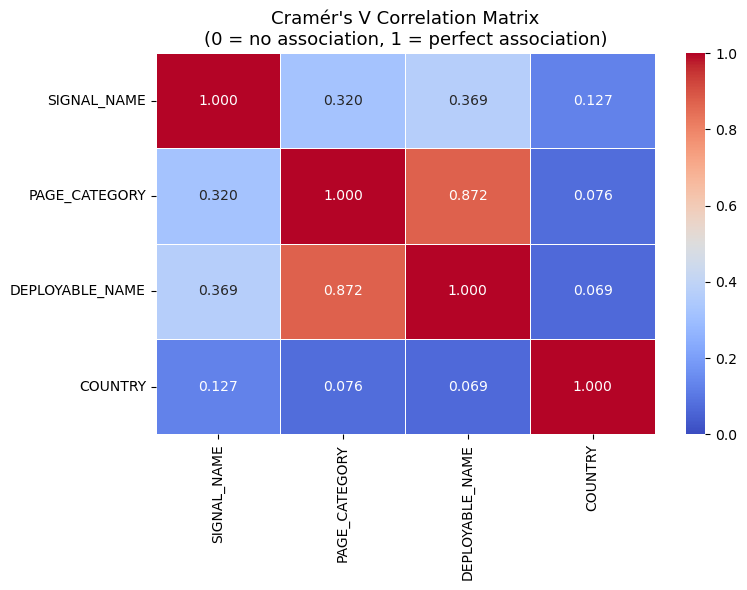

In [30]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cramér's V correlation for categorical variables
# Returns a value between 0 (no association) and 1 (perfect association)
# This is the correct correlation measure for categorical data
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

# Calculate Cramér's V between all variable pairs
variables = ['SIGNAL_NAME', 'PAGE_CATEGORY', 'DEPLOYABLE_NAME', 'COUNTRY']

corr_matrix = pd.DataFrame(index=variables, columns=variables, dtype=float)

for col1 in variables:
    for col2 in variables:
        if col1 == col2:
            corr_matrix.loc[col1, col2] = 1.0
        else:
            corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

print("Cramér's V Correlation Matrix:")
print(corr_matrix.round(3))

# Heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0, vmax=1, linewidths=0.5)
plt.title("Cramér's V Correlation Matrix\n(0 = no association, 1 = perfect association)", fontsize=13)
plt.tight_layout()
plt.savefig('cramers_v_correlation.png', dpi=150)
plt.show()

In [31]:
# Check date ranges across all tables to confirm they overlap
# This is essential before attempting any time-based joins
conn.execute("""
    SELECT 'frustration_signals' as table_name,
        MIN(EVENT_TIME) as earliest,
        MAX(EVENT_TIME) as latest
    FROM frustration_signals
    UNION ALL
    SELECT 'csat',
        MIN("Date") as earliest,
        MAX("Date") as latest
    FROM csat
    UNION ALL
    SELECT 'nps',
        MIN("Date") as earliest,
        MAX("Date") as latest
    FROM nps
    UNION ALL
    SELECT 'support_tickets',
        MIN("Created Date") as earliest,
        MAX("Created Date") as latest
    FROM support_tickets
""").df()

,table_name,earliest,latest
0,frustration_signals,2025-04-17 08:18:10.409,2026-02-05 19:49:13.361
1,csat,1-Apr-20,9-Sep-25
2,nps,1-Apr-25,9-Sep-25
3,support_tickets,1/1/25,"Sep 30, 2025"


In [32]:
# Preview ticket text quality and length to inform our NLP approach
conn.execute("""
    SELECT "Ticket Text", "Product Area", "Roadblock", "Ticket Name"
    FROM support_tickets
    WHERE "Ticket Text" IS NOT NULL
    LIMIT 10
""").df()

,Ticket Text,Product Area,Roadblock,Ticket Name
0,Please see details in images page 1 and page 2...,Sales Email,Sales Email Sending,Can't create new user
1,https://onehomes.com/bloghttps://onehomes.com/...,Help & Resources,Academy,Backslash missing causing page redirects
2,"Hello, I set up a user to have a Manager: Merc...",Properties,Create Property,Choosing a user's manager in a workflow
3,PortalId: PortalId{5595333},Reports,Report Editor,Chat
4,PortalId: PortalId{8084862},Content,Other (Content),Chat
5,How to change default email send time,Marketing Email,Email Settings,Default email send time
6,I would like to cancel and receive Invoice #16...,Billing,Cancellation,Cancel and Refund order
7,PortalId: PortalId{47737617},Business Units,Brand Kit,Manage logos on meeting scheduling page
8,PortalId: PortalId{383440},Billing,Limits,Marketing contact status
9,Multiple users are reporting latency and pages...,File Manager,Other (File Manager),Latency and pages not loading


In [33]:
# Check how many tickets have usable text vs nulls
# We need to know how much data we're actually working with for NLP
conn.execute("""
    SELECT 
        COUNT(*) as total,
        COUNT("Ticket Text") as has_ticket_text,
        COUNT("Ticket Name") as has_ticket_name,
        COUNT("Product Area") as has_product_area,
        COUNT("Roadblock") as has_roadblock
    FROM support_tickets
""").df()

,total,has_ticket_text,has_ticket_name,has_product_area,has_roadblock
0,1048575,429582,970243,785298,783484


In [34]:
# Distribution of tickets by Product Area
# This gives us a structural view before we do any text analysis
conn.execute("""
    SELECT "Product Area", COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM support_tickets
    WHERE "Product Area" IS NOT NULL
    GROUP BY "Product Area"
    ORDER BY count DESC
    LIMIT 20
""").df()

,Product Area,count,percentage
0,Workflows,60891,7.75
1,Marketing Email,57265,7.29
2,Billing,52140,6.64
3,Account Settings,43903,5.59
4,Forms,36913,4.70
5,Reports,35637,4.54
6,Object,30295,3.86
7,Integrations,26311,3.35
8,Login,25399,3.23
9,Content,25309,3.22


Usable tickets for NLP: 901,212
TF-IDF matrix shape: (901212, 500)


/var/folders/vf/2hynqy113sjcb93wgpjr75lh0000gn/T/ipykernel_2052/201310484.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_terms_df, x='score', y='term', palette='YlOrRd_r')


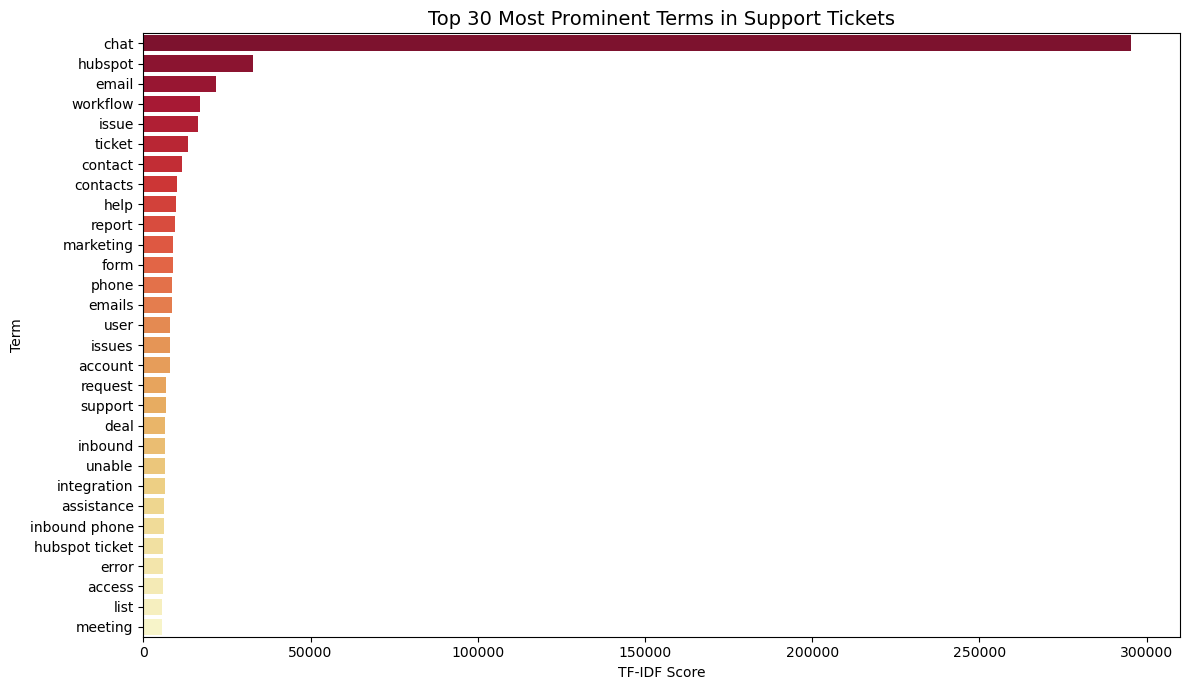


Support Ticket Theme Clusters:
 cluster   size  pct_of_tickets                                                                                             top_terms        top_product_area
       0 350821            38.9                                              chat, form, account, help, user, emails, support, issues                 Billing
       1 284727            31.6                                              chat, code, website, hubspot, enrollment, et, es, errors         Marketing Email
       2  60694             6.7                                hubspot, en, en hubspot, integration, issues, support, emails, account                 Billing
       4  44154             4.9                                 issue, contact, hubspot, form, issue hubspot, company, property, list                  Object
       6  42803             4.7                                  email, issue, hubspot, address, sending, email address, user, issues         Marketing Email
       8  33172     

/var/folders/vf/2hynqy113sjcb93wgpjr75lh0000gn/T/ipykernel_2052/201310484.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_df, x='pct_of_tickets', y='label', palette='Blues_r')


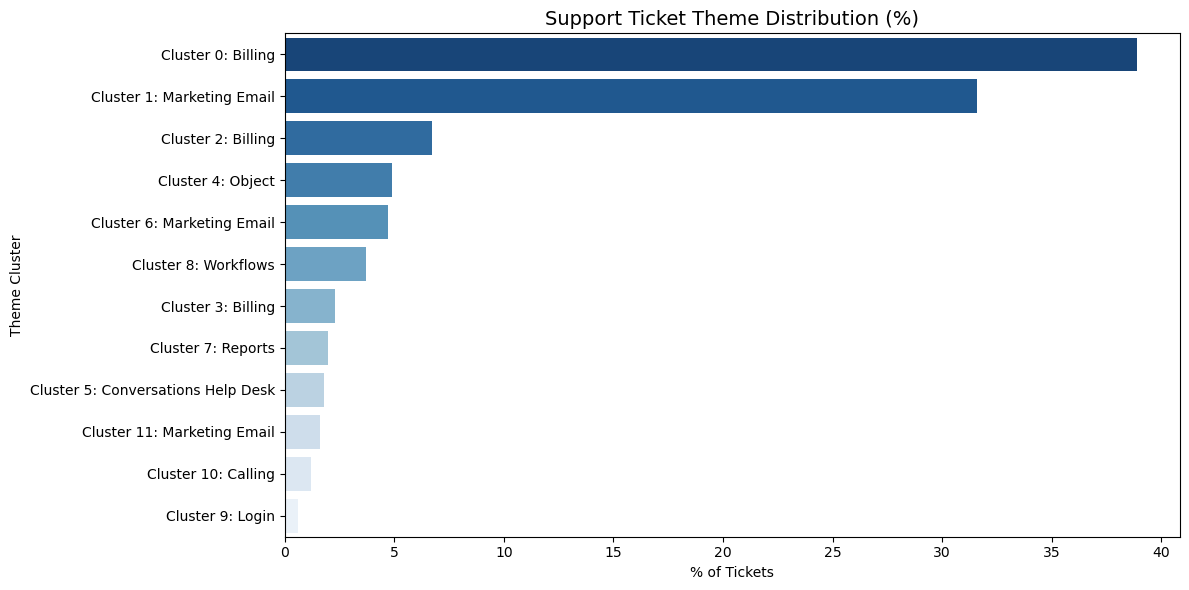

In [35]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ── STEP 1: LOAD DATA ───────────────────────────────────────────────────────
# Using Ticket Name as primary text source (92% coverage vs 41% for Ticket Text)
# Filtering out Portal ID entries which are system-generated and not meaningful for NLP
tickets_df = conn.execute("""
    SELECT "Ticket Name", "Product Area", "Roadblock", "Resolution"
    FROM support_tickets
    WHERE "Ticket Name" IS NOT NULL
      AND "Ticket Name" NOT LIKE 'PortalId%'
      AND LENGTH("Ticket Name") > 10
""").df()

print(f"Usable tickets for NLP: {len(tickets_df):,}")

# ── STEP 2: CLEAN TEXT ──────────────────────────────────────────────────────
# Remove URLs, portal IDs, special characters and normalize whitespace
# so the model only learns from meaningful words
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'portalid[:\s]*\d+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tickets_df['clean_name'] = tickets_df['Ticket Name'].apply(clean_text)

# ── STEP 3: TF-IDF VECTORIZATION ────────────────────────────────────────────
# TF-IDF finds terms important to specific tickets but not generic across all
# ngram_range=(1,2) captures single words and two-word phrases like "email sending"
# min_df=10 removes very rare terms that won't generalize to meaningful themes
vectorizer = TfidfVectorizer(
    max_features=500,
    min_df=10,
    ngram_range=(1, 2),
    stop_words='english'
)
tfidf_matrix = vectorizer.fit_transform(tickets_df['clean_name'])
feature_names = vectorizer.get_feature_names_out()
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# ── STEP 4: TOP TERMS CHART ─────────────────────────────────────────────────
# Overall most prominent terms across all tickets
# Gives a vocabulary-level view of what customers struggle with most
tfidf_scores = tfidf_matrix.sum(axis=0).A1
top_terms_df = pd.DataFrame({'term': feature_names, 'score': tfidf_scores})
top_terms_df = top_terms_df.sort_values('score', ascending=False).head(30)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_terms_df, x='score', y='term', palette='YlOrRd_r')
plt.title('Top 30 Most Prominent Terms in Support Tickets', fontsize=14)
plt.xlabel('TF-IDF Score')
plt.ylabel('Term')
plt.tight_layout()
plt.savefig('top_ticket_terms.png', dpi=150)
plt.show()

# ── STEP 5: K-MEANS CLUSTERING ──────────────────────────────────────────────
# Groups tickets into 12 themes based on semantic similarity of ticket names
# 12 clusters targets the 10-15 themes we are looking for
# n_init=10 runs the algorithm 10 times and picks the best result for stability
kmeans = KMeans(n_clusters=12, random_state=42, n_init=10)
tickets_df['cluster'] = kmeans.fit_predict(tfidf_matrix)

# ── STEP 6: LABEL EACH CLUSTER ──────────────────────────────────────────────
# Extract top 8 terms from each cluster center to describe the theme
# Also capture cluster size and dominant product area for context
def get_cluster_terms(cluster_id, n_terms=8):
    center = kmeans.cluster_centers_[cluster_id]
    top_indices = center.argsort()[-n_terms:][::-1]
    return ', '.join([feature_names[i] for i in top_indices])

cluster_summary = []
for i in range(12):
    cluster_tickets = tickets_df[tickets_df['cluster'] == i]
    top_area = cluster_tickets['Product Area'].value_counts()
    cluster_summary.append({
        'cluster': i,
        'size': len(cluster_tickets),
        'pct_of_tickets': round(len(cluster_tickets) / len(tickets_df) * 100, 1),
        'top_terms': get_cluster_terms(i),
        'top_product_area': top_area.index[0] if len(top_area) > 0 else 'N/A'
    })

cluster_df = pd.DataFrame(cluster_summary).sort_values('size', ascending=False)
print("\nSupport Ticket Theme Clusters:")
print(cluster_df.to_string(index=False))

# ── STEP 7: CLUSTER SIZE VISUALIZATION ──────────────────────────────────────
# Visual summary of theme cluster sizes to prioritize which areas to address first
cluster_df['label'] = cluster_df.apply(
    lambda r: f"Cluster {r['cluster']}: {r['top_product_area']}", axis=1
)

plt.figure(figsize=(12, 6))
sns.barplot(data=cluster_df, x='pct_of_tickets', y='label', palette='Blues_r')
plt.title('Support Ticket Theme Distribution (%)', fontsize=14)
plt.xlabel('% of Tickets')
plt.ylabel('Theme Cluster')
plt.tight_layout()
plt.savefig('ticket_themes.png', dpi=150)
plt.show()

/var/folders/vf/2hynqy113sjcb93wgpjr75lh0000gn/T/ipykernel_2052/2122203729.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nps_raw['date_dt'] = pd.to_datetime(nps_raw['Date'], errors='coerce')
/var/folders/vf/2hynqy113sjcb93wgpjr75lh0000gn/T/ipykernel_2052/2122203729.py:65: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  csat_raw['date_dt'] = pd.to_datetime(csat_raw['Date'], errors='coerce')


Frustration signal weeks: 20
Ticket weeks: 27
NPS weeks: 27
CSAT weeks: 27

Merged weekly dataset: (20, 10)
        week  signal_count  rage_clicks  repeated_nav  dead_clicks  \
0 2025-04-14             5            5             0            0   
1 2025-05-12             5            1             0            4   
2 2025-06-02             4            1             0            1   
3 2025-06-09             2            0             0            2   
4 2025-06-16            42            1             0           41   

   doom_scrolls  text_highlighting  ticket_count  avg_nps_score  \
0             0                  0             6       6.609302   
1             0                  0             7       6.716895   
2             2                  0             6       6.870192   
3             0                  0             9       6.976285   
4             0                  0            12       6.927419   

   avg_csat_score  
0        3.888889  
1        3.856403  
2       

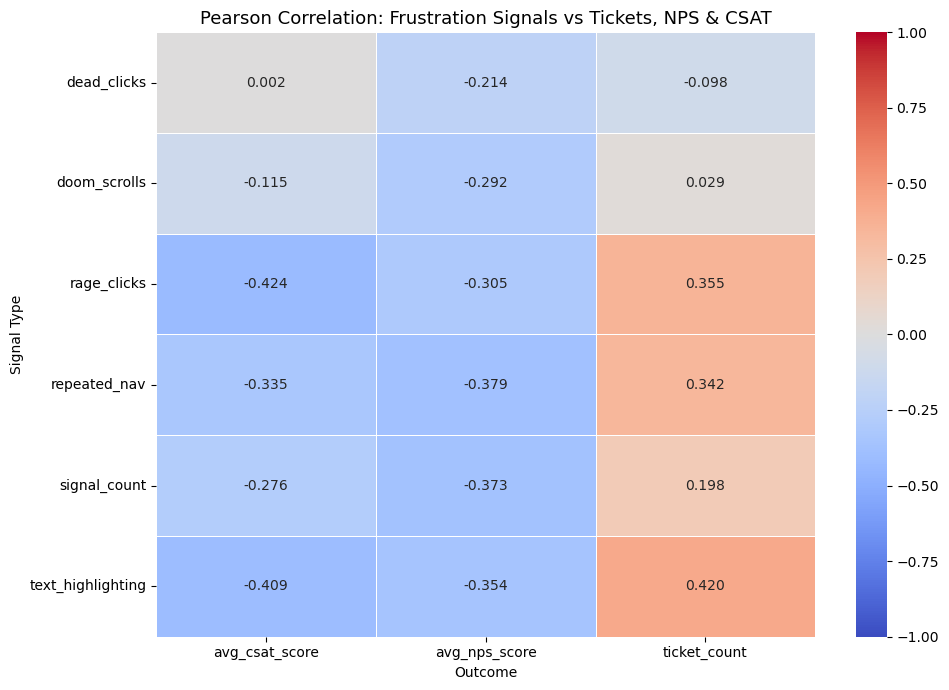

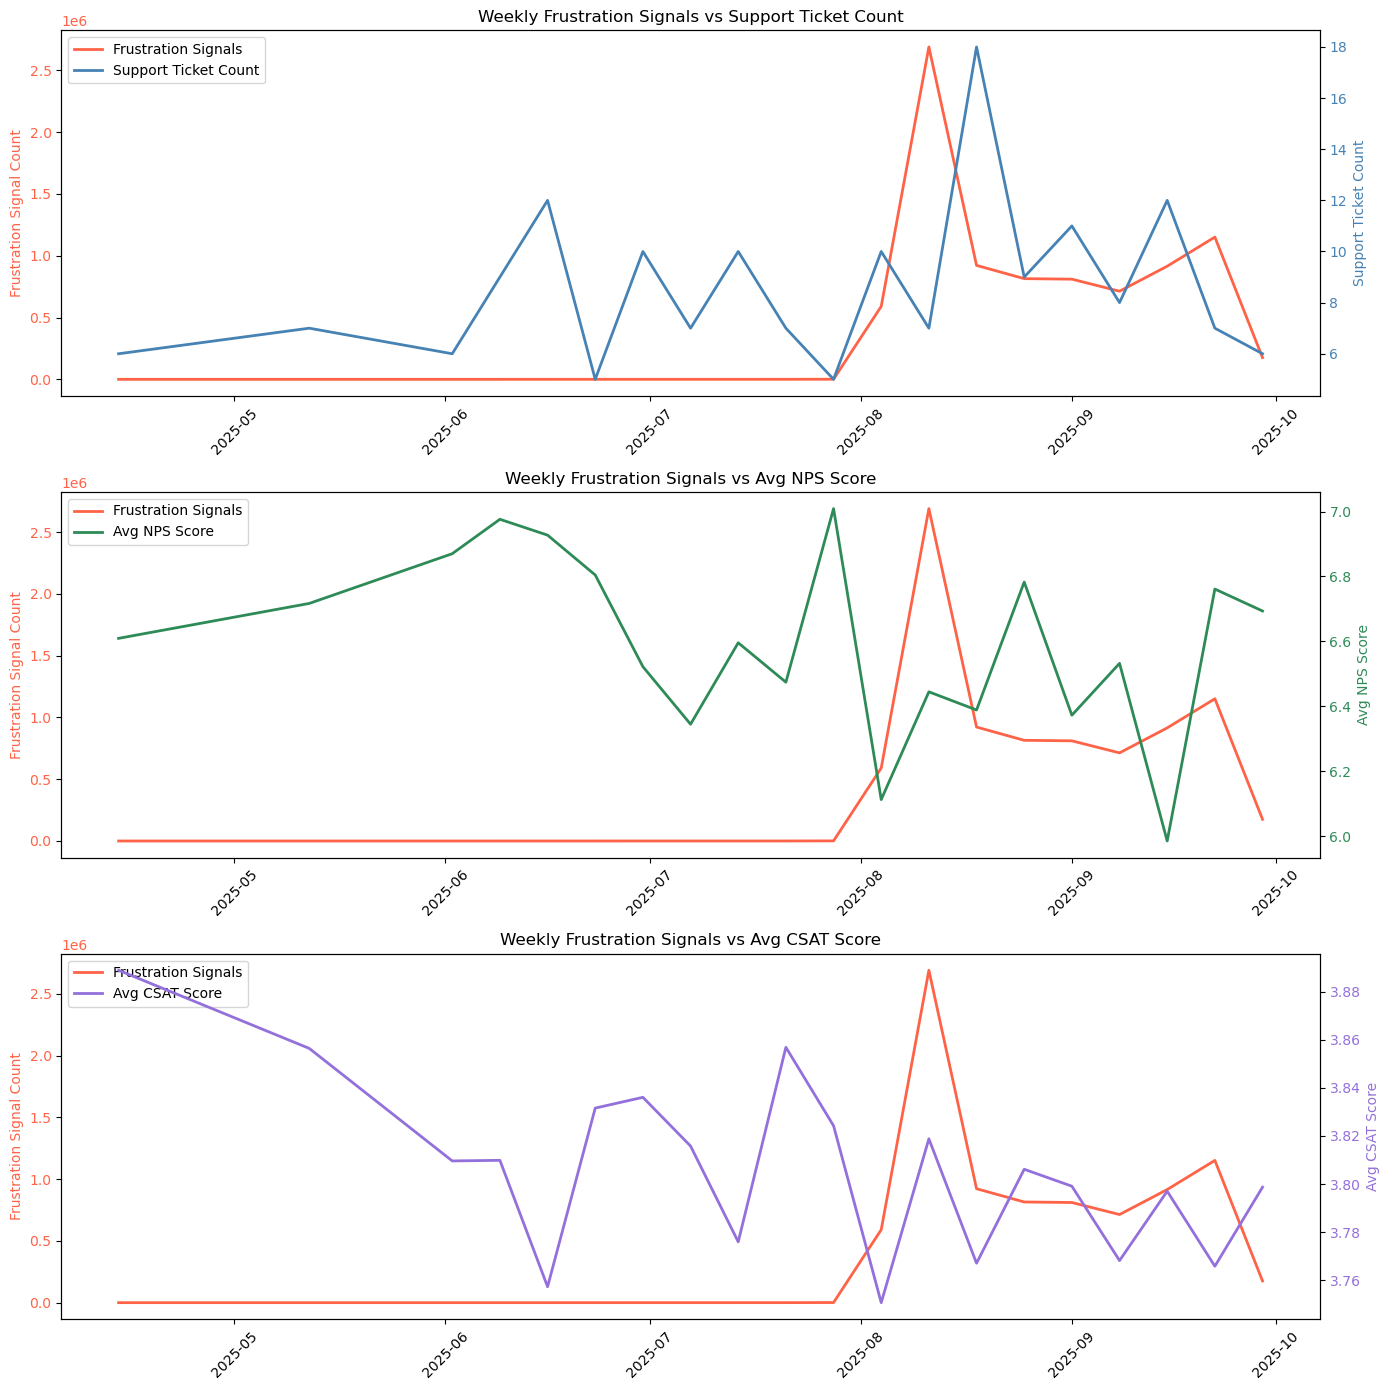

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ── STEP 1: AGGREGATE FRUSTRATION SIGNALS GLOBALLY BY WEEK ──────────────────
fs_global_weekly = conn.execute("""
    SELECT 
        DATE_TRUNC('week', CAST(EVENT_TIME AS TIMESTAMP)) as week,
        COUNT(*) as signal_count,
        COUNT(CASE WHEN SIGNAL_NAME = '"Rage Click"' THEN 1 END) as rage_clicks,
        COUNT(CASE WHEN SIGNAL_NAME = '"Repeated Navigation"' THEN 1 END) as repeated_nav,
        COUNT(CASE WHEN SIGNAL_NAME = '"Dead Click"' THEN 1 END) as dead_clicks,
        COUNT(CASE WHEN SIGNAL_NAME = '"Doom Scroll"' THEN 1 END) as doom_scrolls,
        COUNT(CASE WHEN SIGNAL_NAME = '"Text Highlighting"' THEN 1 END) as text_highlighting
    FROM frustration_signals
    WHERE CAST(EVENT_TIME AS TIMESTAMP) >= '2025-04-01'
      AND CAST(EVENT_TIME AS TIMESTAMP) <= '2025-09-30'
    GROUP BY DATE_TRUNC('week', CAST(EVENT_TIME AS TIMESTAMP))
    ORDER BY week
""").df()

# ── STEP 2: AGGREGATE SUPPORT TICKETS BY WEEK ───────────────────────────────
# Created Date is in M/D/YY format so we parse it in Python instead of SQL
tickets_raw = conn.execute("""
    SELECT "Created Date"
    FROM support_tickets
    WHERE "Created Date" IS NOT NULL
""").df()

# Parse the inconsistent date format in Python using pandas
tickets_raw['created_dt'] = pd.to_datetime(tickets_raw['Created Date'], errors='coerce')
tickets_raw = tickets_raw.dropna(subset=['created_dt'])
tickets_raw = tickets_raw[
    (tickets_raw['created_dt'] >= '2025-04-01') & 
    (tickets_raw['created_dt'] <= '2025-09-30')
]
tickets_raw['week'] = tickets_raw['created_dt'].dt.to_period('W').apply(lambda r: r.start_time)
tickets_weekly = tickets_raw.groupby('week').size().reset_index(name='ticket_count')

# ── STEP 3: AGGREGATE NPS SCORES BY WEEK ────────────────────────────────────
nps_raw = conn.execute("""
    SELECT "Date", "Score"
    FROM nps
    WHERE "Date" IS NOT NULL AND "Score" IS NOT NULL
""").df()

nps_raw['date_dt'] = pd.to_datetime(nps_raw['Date'], errors='coerce')
nps_raw = nps_raw.dropna(subset=['date_dt'])
nps_raw = nps_raw[
    (nps_raw['date_dt'] >= '2025-04-01') & 
    (nps_raw['date_dt'] <= '2025-09-30')
]
nps_raw['week'] = nps_raw['date_dt'].dt.to_period('W').apply(lambda r: r.start_time)
nps_weekly = nps_raw.groupby('week')['Score'].mean().reset_index(name='avg_nps_score')

# ── STEP 4: AGGREGATE CSAT SCORES BY WEEK ───────────────────────────────────
csat_raw = conn.execute("""
    SELECT "Date", "Score"
    FROM csat
    WHERE "Date" IS NOT NULL AND "Score" IS NOT NULL
""").df()

csat_raw['date_dt'] = pd.to_datetime(csat_raw['Date'], errors='coerce')
csat_raw = csat_raw.dropna(subset=['date_dt'])
csat_raw = csat_raw[
    (csat_raw['date_dt'] >= '2025-04-01') & 
    (csat_raw['date_dt'] <= '2025-09-30')
]
csat_raw['week'] = csat_raw['date_dt'].dt.to_period('W').apply(lambda r: r.start_time)
csat_weekly = csat_raw.groupby('week')['Score'].mean().reset_index(name='avg_csat_score')

print(f"Frustration signal weeks: {len(fs_global_weekly)}")
print(f"Ticket weeks: {len(tickets_weekly)}")
print(f"NPS weeks: {len(nps_weekly)}")
print(f"CSAT weeks: {len(csat_weekly)}")

# ── STEP 5: MERGE ALL TABLES ON WEEK ────────────────────────────────────────
fs_global_weekly['week'] = pd.to_datetime(fs_global_weekly['week'])
tickets_weekly['week'] = pd.to_datetime(tickets_weekly['week'])
nps_weekly['week'] = pd.to_datetime(nps_weekly['week'])
csat_weekly['week'] = pd.to_datetime(csat_weekly['week'])

merged = fs_global_weekly \
    .merge(tickets_weekly, on='week', how='inner') \
    .merge(nps_weekly, on='week', how='inner') \
    .merge(csat_weekly, on='week', how='inner')

print(f"\nMerged weekly dataset: {merged.shape}")
print(merged.head())

# ── STEP 6: PEARSON CORRELATION FOR ALL THREE OUTCOMES ──────────────────────
signal_cols = ['signal_count', 'rage_clicks', 'repeated_nav',
               'dead_clicks', 'doom_scrolls', 'text_highlighting']
outcome_cols = ['ticket_count', 'avg_nps_score', 'avg_csat_score']

correlation_results = []
for signal in signal_cols:
    for outcome in outcome_cols:
        if merged[signal].std() > 0 and merged[outcome].std() > 0:
            r, p = pearsonr(merged[signal], merged[outcome])
            correlation_results.append({
                'signal': signal,
                'outcome': outcome,
                'pearson_r': round(r, 3),
                'p_value': round(p, 4),
                'significant': 'Yes' if p < 0.05 else 'No'
            })

corr_df = pd.DataFrame(correlation_results)
print("\nFull Correlation Results:")
print(corr_df.to_string(index=False))

# ── STEP 7: CORRELATION HEATMAP ─────────────────────────────────────────────
pivot_corr = corr_df.pivot(index='signal', columns='outcome', values='pearson_r')

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation: Frustration Signals vs Tickets, NPS & CSAT', fontsize=13)
plt.xlabel('Outcome')
plt.ylabel('Signal Type')
plt.tight_layout()
plt.savefig('full_correlation_heatmap.png', dpi=150)
plt.show()

# ── STEP 8: TIME SERIES OVERLAY ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

outcomes = [
    ('ticket_count', 'Support Ticket Count', 'steelblue'),
    ('avg_nps_score', 'Avg NPS Score', 'seagreen'),
    ('avg_csat_score', 'Avg CSAT Score', 'mediumpurple')
]

for ax, (outcome_col, outcome_label, color) in zip(axes, outcomes):
    ax2 = ax.twinx()
    ax.plot(merged['week'], merged['signal_count'],
            color='tomato', linewidth=2, label='Frustration Signals')
    ax.set_ylabel('Frustration Signal Count', color='tomato')
    ax.tick_params(axis='y', labelcolor='tomato')
    ax2.plot(merged['week'], merged[outcome_col],
             color=color, linewidth=2, label=outcome_label)
    ax2.set_ylabel(outcome_label, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax.set_title(f'Weekly Frustration Signals vs {outcome_label}', fontsize=12)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('signal_vs_outcomes_timeseries.png', dpi=150)
plt.show()

Base dataset for lag analysis: (20, 10)

Full Lag Correlation Results:
 lag_weeks            signal        outcome  pearson_r  p_value significant
         0      signal_count   ticket_count      0.198   0.4031          No
         0      signal_count  avg_nps_score     -0.373   0.1056          No
         0      signal_count avg_csat_score     -0.276   0.2394          No
         0       rage_clicks   ticket_count      0.355   0.1248          No
         0       rage_clicks  avg_nps_score     -0.305   0.1909          No
         0       rage_clicks avg_csat_score     -0.424   0.0623          No
         0      repeated_nav   ticket_count      0.342   0.1399          No
         0      repeated_nav  avg_nps_score     -0.379   0.0990          No
         0      repeated_nav avg_csat_score     -0.335   0.1487          No
         0       dead_clicks   ticket_count     -0.098   0.6805          No
         0       dead_clicks  avg_nps_score     -0.214   0.3647          No
         0       

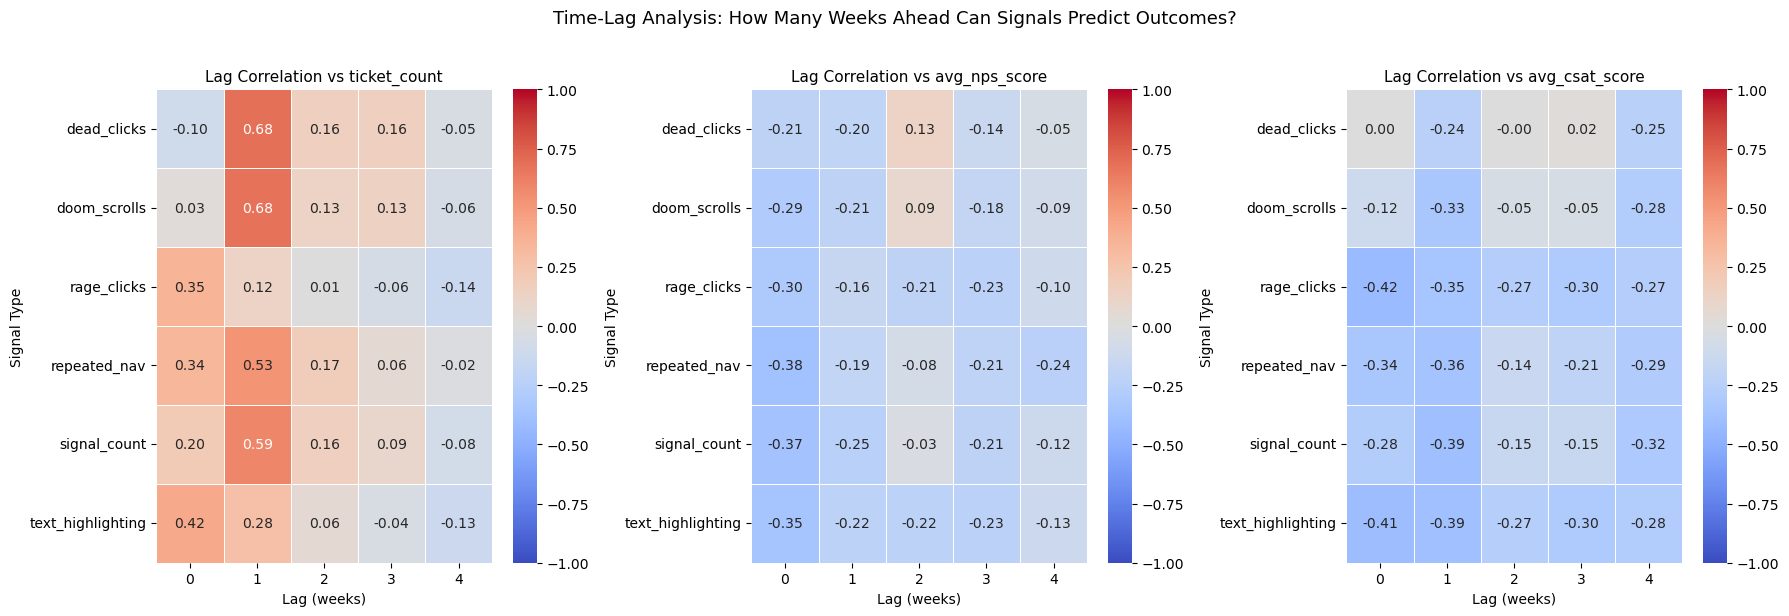

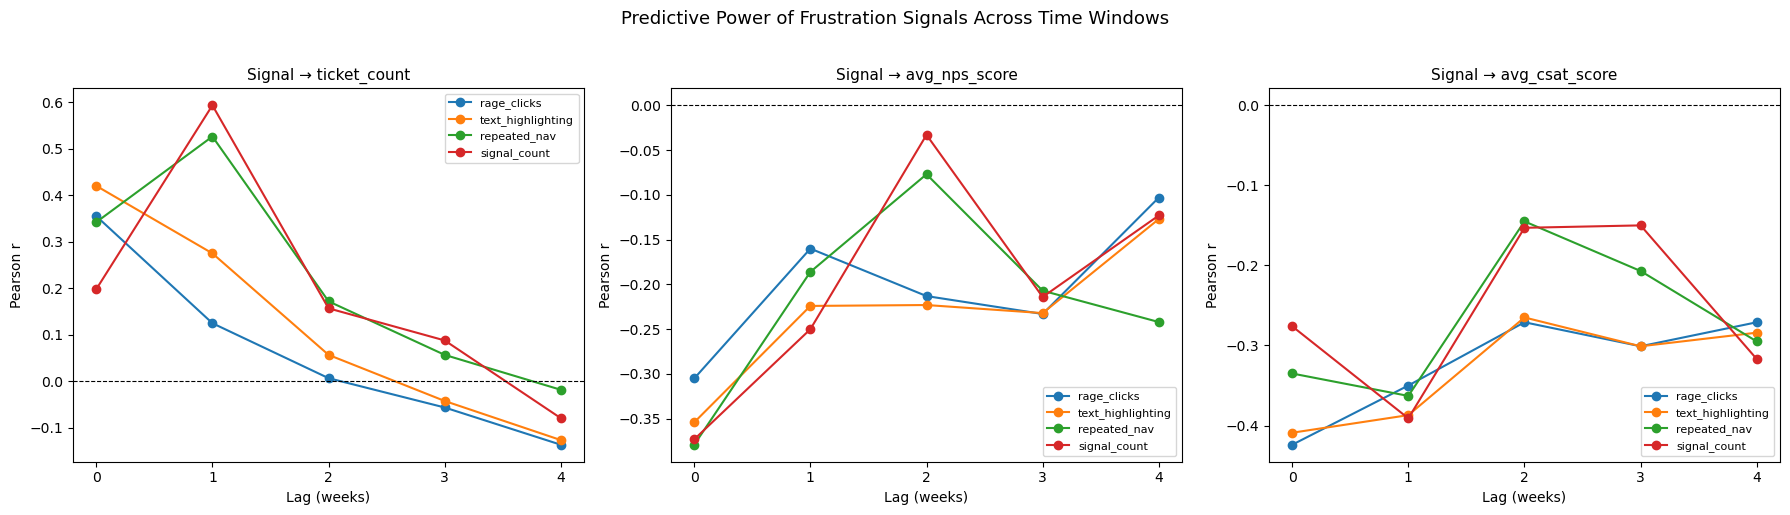

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ── TIME-LAG ANALYSIS ────────────────────────────────────────────────────────
# Tests whether frustration signals PRECEDE support tickets by 1-4 weeks
# A strong correlation at lag=1 means "high frustration this week → high tickets next week"
# This is the key analysis for early warning system potential

# ── STEP 1: REUSE WEEKLY AGGREGATIONS FROM CORRELATION ANALYSIS ──────────────
# fs_global_weekly and tickets_weekly already created in previous cell
# Just need to re-merge them cleanly for lag testing
fs_global_weekly['week'] = pd.to_datetime(fs_global_weekly['week'])
tickets_weekly['week'] = pd.to_datetime(tickets_weekly['week'])
nps_weekly['week'] = pd.to_datetime(nps_weekly['week'])
csat_weekly['week'] = pd.to_datetime(csat_weekly['week'])

base = fs_global_weekly \
    .merge(tickets_weekly, on='week', how='inner') \
    .merge(nps_weekly, on='week', how='inner') \
    .merge(csat_weekly, on='week', how='inner') \
    .sort_values('week') \
    .reset_index(drop=True)

print(f"Base dataset for lag analysis: {base.shape}")

# ── STEP 2: CREATE LAGGED VERSIONS OF OUTCOME VARIABLES ─────────────────────
# lag=1 means: does this week's frustration predict NEXT week's tickets/NPS/CSAT?
# lag=2 means: does this week's frustration predict tickets/NPS/CSAT in 2 weeks?
# We test lags 0 through 4 weeks to find the strongest predictive window
max_lag = 4

signal_cols = ['signal_count', 'rage_clicks', 'repeated_nav',
               'dead_clicks', 'doom_scrolls', 'text_highlighting']
outcome_cols = ['ticket_count', 'avg_nps_score', 'avg_csat_score']

lag_results = []

for lag in range(0, max_lag + 1):
    for signal in signal_cols:
        for outcome in outcome_cols:
            # Shift outcome variable backward by lag weeks
            # so we're comparing this week's signal to future weeks' outcomes
            signal_series = base[signal].iloc[:-lag] if lag > 0 else base[signal]
            outcome_series = base[outcome].shift(-lag).dropna()

            # Align lengths
            min_len = min(len(signal_series), len(outcome_series))
            s = signal_series.iloc[:min_len]
            o = outcome_series.iloc[:min_len]

            if s.std() > 0 and o.std() > 0 and len(s) > 3:
                r, p = pearsonr(s, o)
                lag_results.append({
                    'lag_weeks': lag,
                    'signal': signal,
                    'outcome': outcome,
                    'pearson_r': round(r, 3),
                    'p_value': round(p, 4),
                    'significant': 'Yes' if p < 0.05 else 'No'
                })

lag_df = pd.DataFrame(lag_results)
print("\nFull Lag Correlation Results:")
print(lag_df.to_string(index=False))

# ── STEP 3: FIND OPTIMAL LAG PER SIGNAL-OUTCOME PAIR ────────────────────────
# For each signal + outcome combination, find which lag gives the strongest correlation
# This tells us the optimal early warning window for each signal type
best_lags = lag_df.loc[lag_df.groupby(['signal', 'outcome'])['pearson_r'].apply(lambda x: x.abs().idxmax())]
print("\nBest Lag Per Signal-Outcome Pair:")
print(best_lags[['signal', 'outcome', 'lag_weeks', 'pearson_r', 'p_value']].sort_values('pearson_r').to_string(index=False))

# ── STEP 4: LAG HEATMAP PER OUTCOME ─────────────────────────────────────────
# One heatmap per outcome showing how correlation strength changes across lags
# Helps visualize whether predictive power increases or decreases with time
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, outcome in zip(axes, outcome_cols):
    subset = lag_df[lag_df['outcome'] == outcome]
    pivot = subset.pivot(index='signal', columns='lag_weeks', values='pearson_r')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'Lag Correlation vs {outcome}', fontsize=11)
    ax.set_xlabel('Lag (weeks)')
    ax.set_ylabel('Signal Type')

plt.suptitle('Time-Lag Analysis: How Many Weeks Ahead Can Signals Predict Outcomes?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('timelag_heatmap.png', dpi=150)
plt.show()

# ── STEP 5: LINE CHART OF LAG CORRELATION FOR TOP SIGNALS ───────────────────
# Shows how Pearson r changes as we look further into the future for each outcome
# A peak at lag=2 means the signal is most predictive 2 weeks before the outcome
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_signals = ['rage_clicks', 'text_highlighting', 'repeated_nav', 'signal_count']

for ax, outcome in zip(axes, outcome_cols):
    for signal in top_signals:
        subset = lag_df[(lag_df['signal'] == signal) & (lag_df['outcome'] == outcome)]
        ax.plot(subset['lag_weeks'], subset['pearson_r'], marker='o', label=signal)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Signal → {outcome}', fontsize=11)
    ax.set_xlabel('Lag (weeks)')
    ax.set_ylabel('Pearson r')
    ax.legend(fontsize=8)
    ax.set_xticks(range(max_lag + 1))

plt.suptitle('Predictive Power of Frustration Signals Across Time Windows',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('timelag_lineplot.png', dpi=150)
plt.show()

Signal Volume by Page Category:
    PAGE_CATEGORY  total_signals  rage_clicks  repeated_nav  dead_clicks  doom_scrolls  text_highlighting  pct_of_total
         contacts        5656892      1339788       3298683            0        398725             595728         26.23
    live-messages        3674924       591041        230111       235982        836187            1776418         17.04
        help-desk        3627544       805171        609061       152495        493381            1530566         16.82
          unknown        3594104       926014        553241       345489        710401            1033448         16.67
reports-dashboard        1464185       539545        205782            0        681717              36372          6.79
            pages         997089       613036        300202            0         53097              29467          4.62
      prospecting         558195       232376         96393       124038         71017              21155          2.59
        

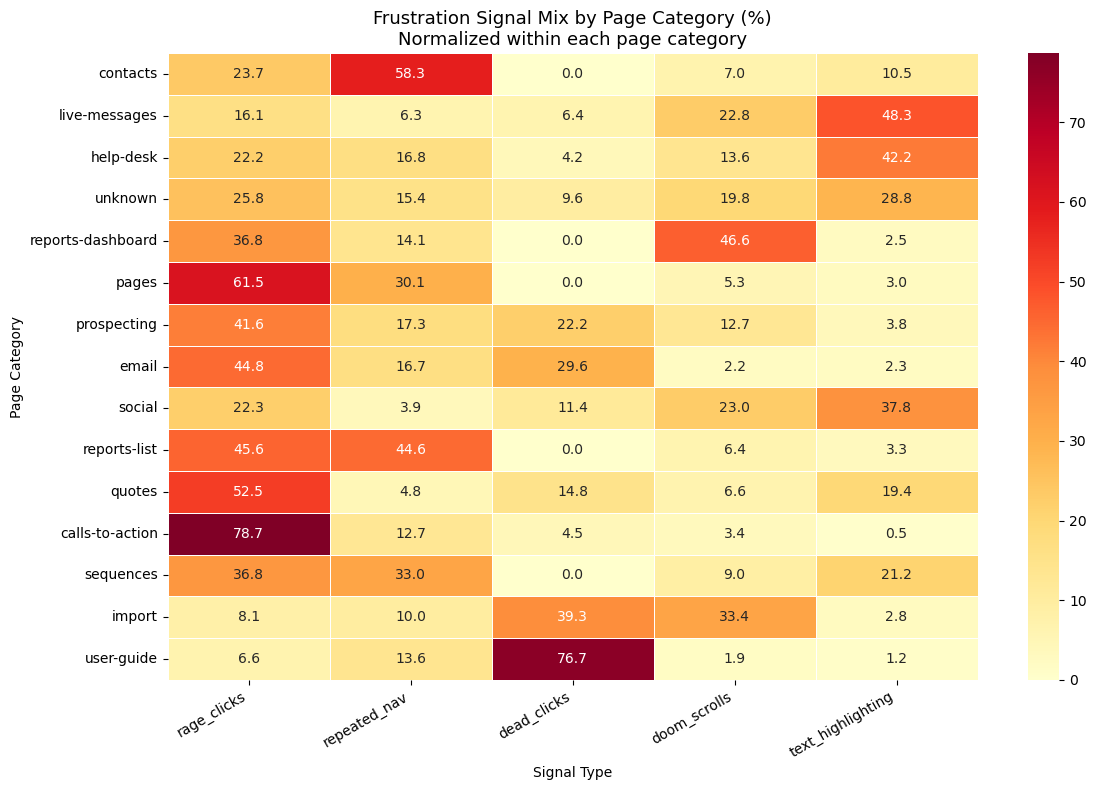


Signal Volume by Deployable:
             DEPLOYABLE_NAME  total_signals  rage_clicks  repeated_nav  dead_clicks  doom_scrolls  text_highlighting  pct_of_total
            "crm-records-ui"        5057353       986960       3074201            0        281233             700128         23.45
    "conversations-inbox-ui"        4612911       704116        280771       323683       1076656            2221832         21.39
             "svh-help-desk"        4567811      1014063        745733       225172        675060            1863067         21.18
               "DashboardUI"        1601714       580646        217714            0        762464              40082          7.43
              "crm-index-ui"        1313893       573267        486644            0        211246              33253          6.09
            "page-editor-ui"        1105170       689212        320990            0         58657              34910          5.12
            "prospecting-ui"         762758       324

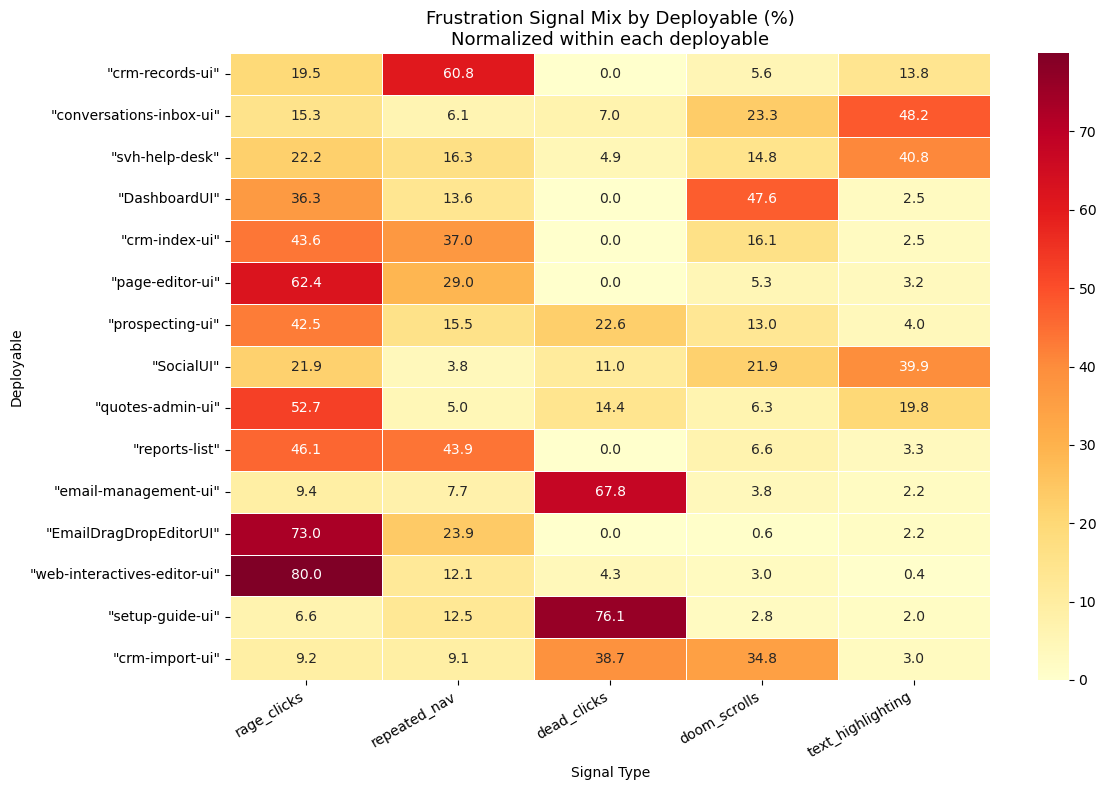

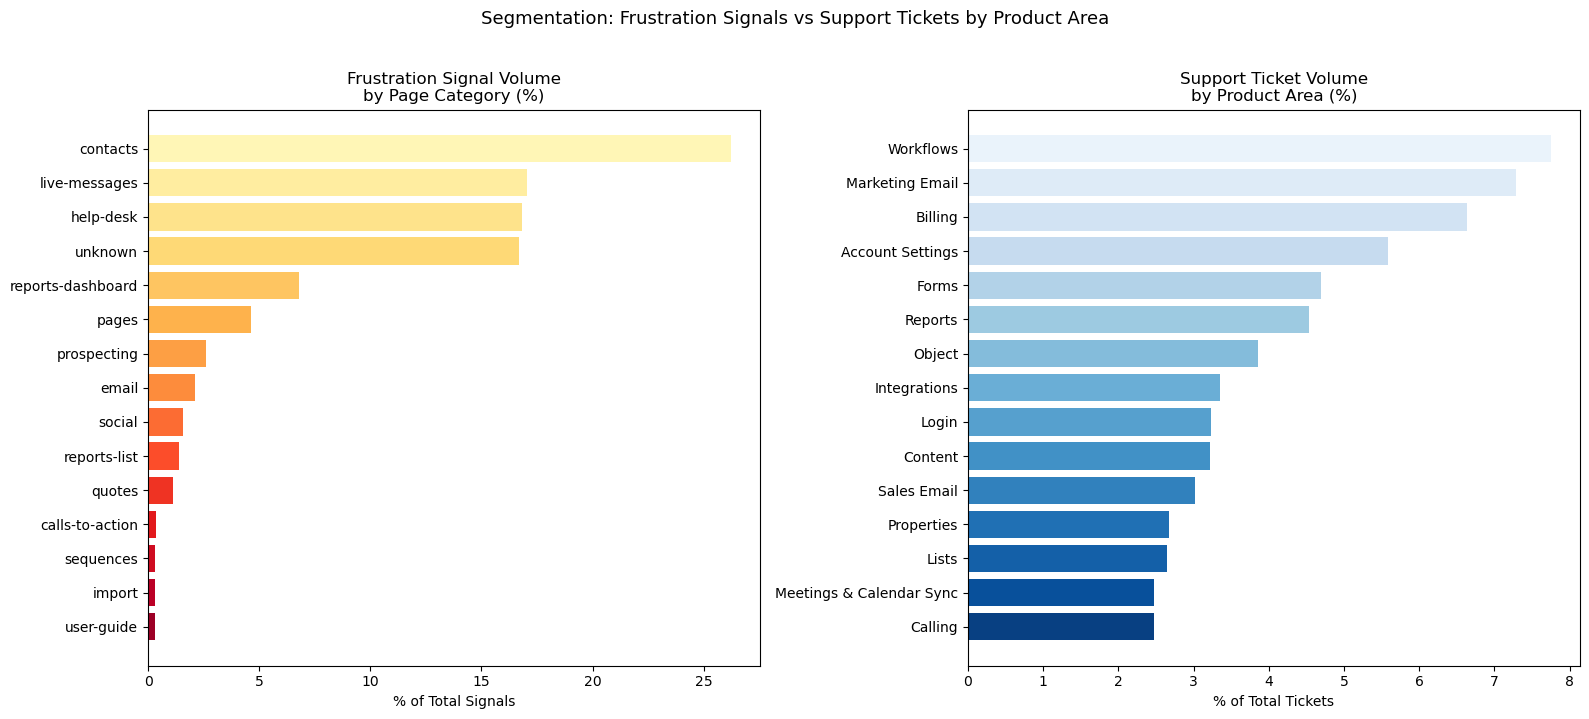


Highest Risk Segments (Dead Click + Doom Scroll concentration):
         PAGE_CATEGORY             DEPLOYABLE_NAME  total_signals  dead_clicks  doom_scrolls  high_risk_signal_pct
               unknown            "setup-guide-ui"          43520        32739          1728                 79.20
            user-guide            "setup-guide-ui"          65377        50130          1267                 78.62
               unknown       "email-management-ui"          62984        46645          1975                 77.19
               unknown             "crm-import-ui"          38452        14486         14258                 74.75
                import             "crm-import-ui"          65526        25772         21915                 72.78
                 email       "email-management-ui"         206039       135765          8370                 69.96
               unknown              "data-sync-ui"          10172         2428          4668                 69.76
             da

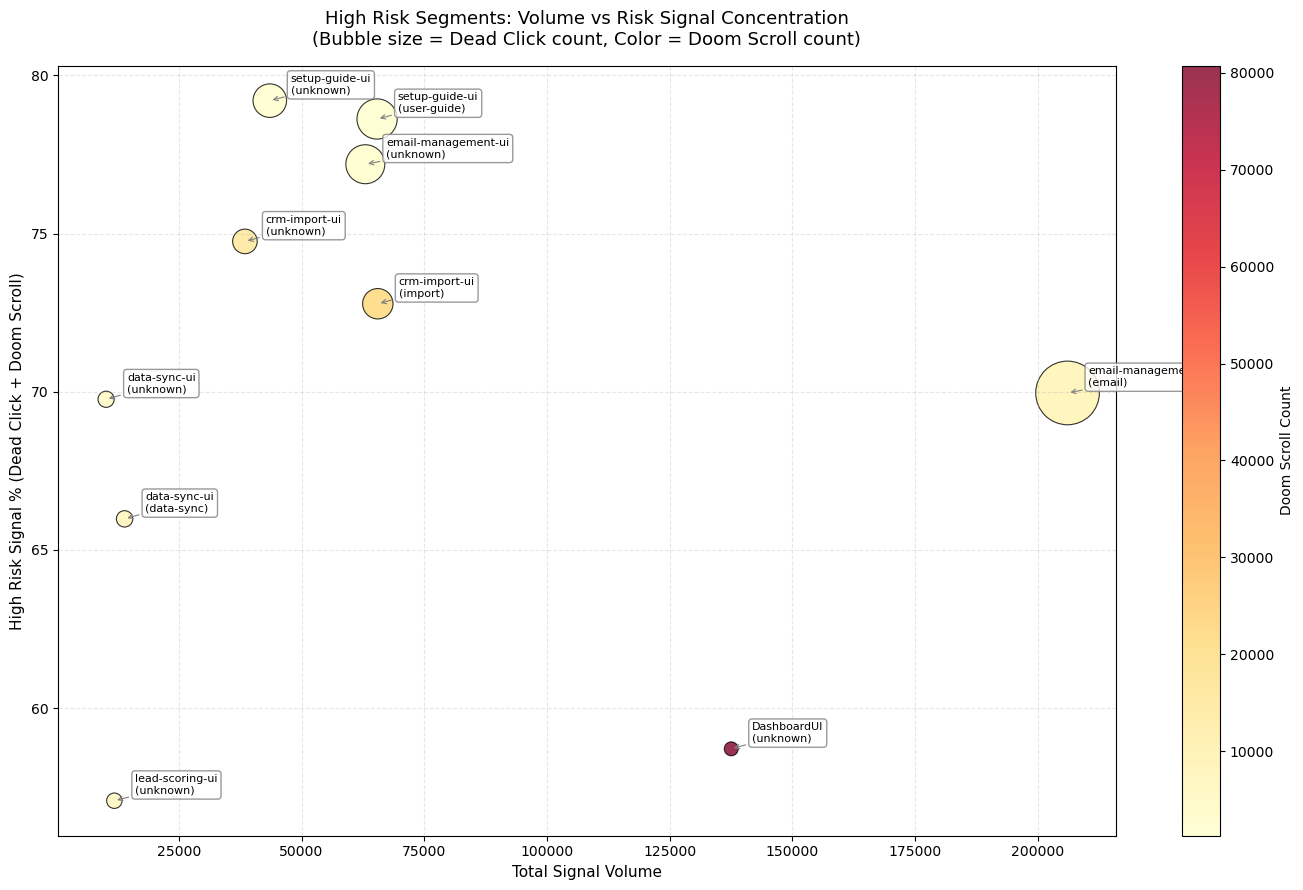

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── SEGMENTATION ANALYSIS ────────────────────────────────────────────────────
# Goal: Understand how frustration signal patterns differ across product areas
# and deployables to identify which segments are most at risk
# Note: New vs power user segmentation is not possible as frustration_signals
# has no user ID field — this is flagged as a data gap for future analysis

# ── STEP 1: SIGNAL VOLUME BY PRODUCT AREA (PAGE CATEGORY) ───────────────────
# Compares total frustration volume across product areas
# Identifies which areas of the product generate disproportionate frustration
segment_page = conn.execute("""
    SELECT 
        PAGE_CATEGORY,
        COUNT(*) as total_signals,
        COUNT(CASE WHEN SIGNAL_NAME = '"Rage Click"' THEN 1 END) as rage_clicks,
        COUNT(CASE WHEN SIGNAL_NAME = '"Repeated Navigation"' THEN 1 END) as repeated_nav,
        COUNT(CASE WHEN SIGNAL_NAME = '"Dead Click"' THEN 1 END) as dead_clicks,
        COUNT(CASE WHEN SIGNAL_NAME = '"Doom Scroll"' THEN 1 END) as doom_scrolls,
        COUNT(CASE WHEN SIGNAL_NAME = '"Text Highlighting"' THEN 1 END) as text_highlighting,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct_of_total
    FROM frustration_signals
    WHERE PAGE_CATEGORY IS NOT NULL
    GROUP BY PAGE_CATEGORY
    ORDER BY total_signals DESC
    LIMIT 15
""").df()

print("Signal Volume by Page Category:")
print(segment_page.to_string(index=False))

# ── STEP 2: SIGNAL MIX HEATMAP BY PAGE CATEGORY ─────────────────────────────
# Normalizes signal counts within each page category to show the MIX of signals
# Reveals whether certain product areas have a unique frustration fingerprint
signal_cols = ['rage_clicks', 'repeated_nav', 'dead_clicks', 'doom_scrolls', 'text_highlighting']
segment_page_norm = segment_page.copy()
segment_page_norm[signal_cols] = segment_page_norm[signal_cols].div(
    segment_page_norm['total_signals'], axis=0) * 100

plt.figure(figsize=(12, 8))
heatmap_data = segment_page_norm.set_index('PAGE_CATEGORY')[signal_cols]
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Frustration Signal Mix by Page Category (%)\nNormalized within each page category', fontsize=13)
plt.xlabel('Signal Type')
plt.ylabel('Page Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('segmentation_page_heatmap.png', dpi=150)
plt.show()

# ── STEP 3: SIGNAL VOLUME BY DEPLOYABLE ─────────────────────────────────────
# Same analysis at the deployable level for more granular product insight
# Deployables are specific UI components — this tells engineering exactly what to fix
segment_deploy = conn.execute("""
    SELECT 
        DEPLOYABLE_NAME,
        COUNT(*) as total_signals,
        COUNT(CASE WHEN SIGNAL_NAME = '"Rage Click"' THEN 1 END) as rage_clicks,
        COUNT(CASE WHEN SIGNAL_NAME = '"Repeated Navigation"' THEN 1 END) as repeated_nav,
        COUNT(CASE WHEN SIGNAL_NAME = '"Dead Click"' THEN 1 END) as dead_clicks,
        COUNT(CASE WHEN SIGNAL_NAME = '"Doom Scroll"' THEN 1 END) as doom_scrolls,
        COUNT(CASE WHEN SIGNAL_NAME = '"Text Highlighting"' THEN 1 END) as text_highlighting,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct_of_total
    FROM frustration_signals
    WHERE DEPLOYABLE_NAME IS NOT NULL
    GROUP BY DEPLOYABLE_NAME
    ORDER BY total_signals DESC
    LIMIT 15
""").df()

print("\nSignal Volume by Deployable:")
print(segment_deploy.to_string(index=False))

# ── STEP 4: SIGNAL MIX HEATMAP BY DEPLOYABLE ────────────────────────────────
# Each deployable has a unique frustration fingerprint
# e.g. DashboardUI may be dominated by Doom Scroll while EmailDragDropEditorUI by Rage Click
segment_deploy_norm = segment_deploy.copy()
segment_deploy_norm[signal_cols] = segment_deploy_norm[signal_cols].div(
    segment_deploy_norm['total_signals'], axis=0) * 100

plt.figure(figsize=(12, 8))
heatmap_data_deploy = segment_deploy_norm.set_index('DEPLOYABLE_NAME')[signal_cols]
sns.heatmap(heatmap_data_deploy, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Frustration Signal Mix by Deployable (%)\nNormalized within each deployable', fontsize=13)
plt.xlabel('Signal Type')
plt.ylabel('Deployable')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('segmentation_deploy_heatmap.png', dpi=150)
plt.show()

# ── STEP 5: CROSS-REFERENCE FRUSTRATION SIGNALS WITH SUPPORT TICKET THEMES ──
# Maps the top frustration page categories to matching support ticket product areas
# This connects the frustration data to real customer complaints
# Helps answer: "Do the pages with most frustration match the most complained about areas?"
ticket_product_area = conn.execute("""
    SELECT 
        "Product Area",
        COUNT(*) as ticket_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct_of_tickets
    FROM support_tickets
    WHERE "Product Area" IS NOT NULL
    GROUP BY "Product Area"
    ORDER BY ticket_count DESC
    LIMIT 15
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(segment_page['PAGE_CATEGORY'], segment_page['pct_of_total'],
             color=sns.color_palette('YlOrRd', len(segment_page)))
axes[0].set_title('Frustration Signal Volume\nby Page Category (%)', fontsize=12)
axes[0].set_xlabel('% of Total Signals')
axes[0].invert_yaxis()

axes[1].barh(ticket_product_area['Product Area'], ticket_product_area['pct_of_tickets'],
             color=sns.color_palette('Blues', len(ticket_product_area)))
axes[1].set_title('Support Ticket Volume\nby Product Area (%)', fontsize=12)
axes[1].set_xlabel('% of Total Tickets')
axes[1].invert_yaxis()

plt.suptitle('Segmentation: Frustration Signals vs Support Tickets by Product Area',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('segmentation_comparison.png', dpi=150)
plt.show()

# ── STEP 6: HIGH RISK SEGMENTS ───────────────────────────────────────────────
# Identifies the highest risk page+deployable combinations
# High risk = high volume of Dead Clicks or Doom Scrolls since these
# showed the strongest 1-week predictive power for support tickets in the lag analysis
high_risk = conn.execute("""
    SELECT 
        PAGE_CATEGORY,
        DEPLOYABLE_NAME,
        COUNT(*) as total_signals,
        COUNT(CASE WHEN SIGNAL_NAME = '"Dead Click"' THEN 1 END) as dead_clicks,
        COUNT(CASE WHEN SIGNAL_NAME = '"Doom Scroll"' THEN 1 END) as doom_scrolls,
        ROUND((COUNT(CASE WHEN SIGNAL_NAME = '"Dead Click"' THEN 1 END) + 
               COUNT(CASE WHEN SIGNAL_NAME = '"Doom Scroll"' THEN 1 END)) * 100.0 / 
               COUNT(*), 2) as high_risk_signal_pct
    FROM frustration_signals
    WHERE PAGE_CATEGORY IS NOT NULL 
      AND DEPLOYABLE_NAME IS NOT NULL
    GROUP BY PAGE_CATEGORY, DEPLOYABLE_NAME
    HAVING COUNT(*) > 10000
    ORDER BY high_risk_signal_pct DESC
    LIMIT 15
""").df()

print("\nHighest Risk Segments (Dead Click + Doom Scroll concentration):")
print(high_risk.to_string(index=False))

# ── STEP 7: HIGH RISK SEGMENT VISUALIZATION (IMPROVED) ──────────────────────
# Bubble chart showing risk level by segment
# X = total signal volume, Y = high risk signal %, bubble size = dead clicks
# Color = doom scroll count
# Segments in the top right are highest priority: high volume AND high risk signal mix
# Labels use white boxes with arrows to avoid overlap
# Limited to top 10 segments for readability

high_risk_top10 = high_risk.head(10).copy()

fig, ax = plt.subplots(figsize=(14, 9))

# Normalize bubble sizes so they are proportional but readable
bubble_sizes = (high_risk_top10['dead_clicks'] / high_risk_top10['dead_clicks'].max()) * 2000 + 100

scatter = ax.scatter(
    high_risk_top10['total_signals'],
    high_risk_top10['high_risk_signal_pct'],
    s=bubble_sizes,
    c=high_risk_top10['doom_scrolls'],
    cmap='YlOrRd',
    alpha=0.8,
    edgecolors='black',
    linewidth=0.8
)

plt.colorbar(scatter, ax=ax, label='Doom Scroll Count')

# White box labels with arrows to prevent overlap and improve readability
for _, row in high_risk_top10.iterrows():
    label = f"{row['DEPLOYABLE_NAME'].replace(chr(34), '')[:25]}\n({row['PAGE_CATEGORY']})"
    ax.annotate(
        label,
        xy=(row['total_signals'], row['high_risk_signal_pct']),
        xytext=(15, 5),
        textcoords='offset points',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8),
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

ax.set_title('High Risk Segments: Volume vs Risk Signal Concentration\n(Bubble size = Dead Click count, Color = Doom Scroll count)',
             fontsize=13, pad=15)
ax.set_xlabel('Total Signal Volume', fontsize=11)
ax.set_ylabel('High Risk Signal % (Dead Click + Doom Scroll)', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('segmentation_risk_bubble_v2.png', dpi=150)
plt.show()

Theme Map: Ticket Complaints → Frustration Signal Patterns
                      ticket_theme   nlp_cluster     ticket_product_area matching_page_category     dominant_signal dominant_signal_pct                                                                                                                                interpretation
        Workflow Enrollment Issues     Cluster 8               Workflows              sequences Repeated Navigation               33.0%                                               Users repeatedly navigate trying to find workflow settings — confusion with workflow setup flow
Marketing Email & Sending Failures Cluster 1 & 6         Marketing Email                  email          Rage Click               44.8%                                                         High rage click rate on email pages suggests broken UI elements in email sending flow
          Billing & Account Issues Cluster 0 & 2                 Billing                unknown          De

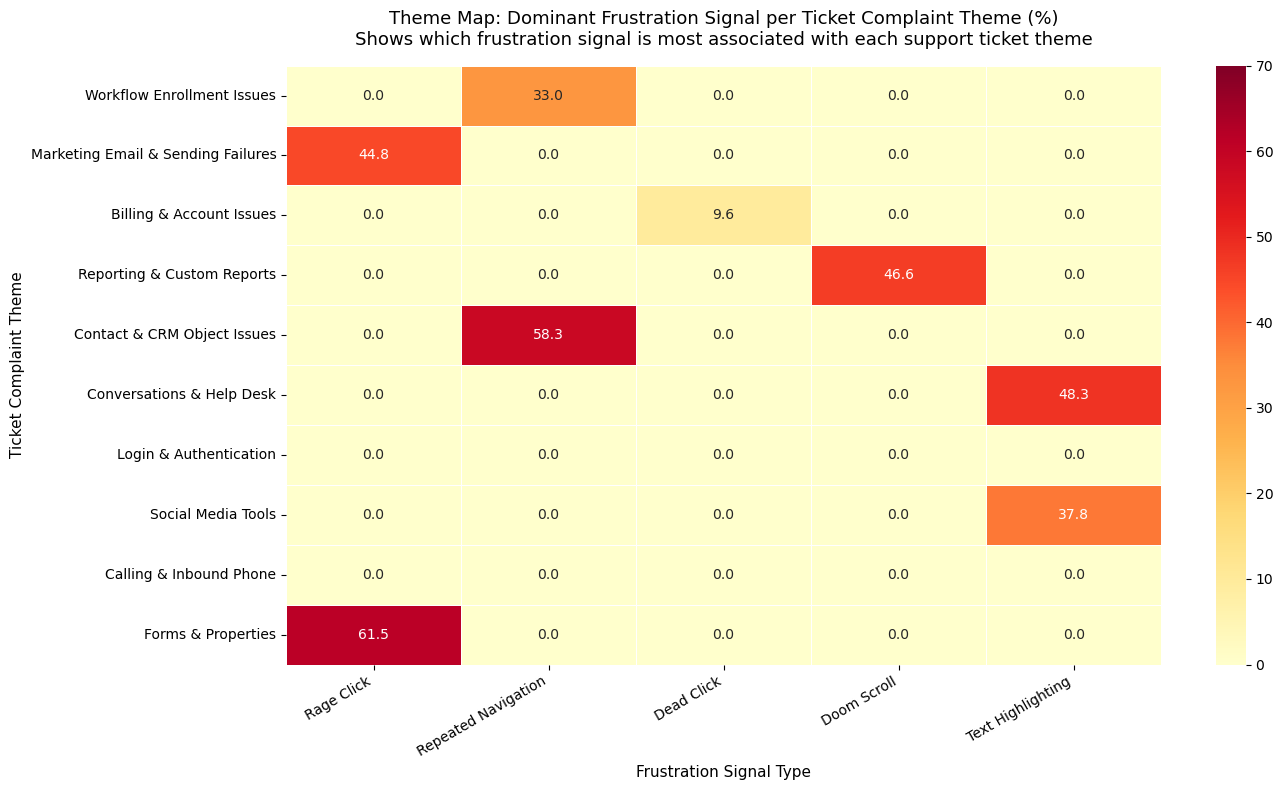


Priority Matrix: Ranked by Combined Ticket + Signal Volume
Empty DataFrame
Columns: [Product Area, ticket_count, total_signals, dominant_signal, dominant_signal_pct, top_roadblock, priority_score]
Index: []


In [42]:
# ── THEME MAP: TICKET COMPLAINTS → FRUSTRATION SIGNAL PATTERNS ──────────────
# Goal: Formally connect support ticket complaint themes to frustration signal patterns
# This answers: "When customers complain about X, which frustration signals preceded it?"
# Based on matching ticket Product Areas to frustration signal Page Categories
# This is the bridge between what customers report and what the product data shows

# ── STEP 1: AGGREGATE FRUSTRATION SIGNALS BY PAGE CATEGORY ──────────────────
# Get the dominant signal type and mix for each page category
# This gives us the "frustration fingerprint" of each product area
signal_by_page = conn.execute("""
    SELECT 
        PAGE_CATEGORY,
        COUNT(*) as total_signals,
        COUNT(CASE WHEN SIGNAL_NAME = '"Rage Click"' THEN 1 END) as rage_clicks,
        COUNT(CASE WHEN SIGNAL_NAME = '"Repeated Navigation"' THEN 1 END) as repeated_nav,
        COUNT(CASE WHEN SIGNAL_NAME = '"Dead Click"' THEN 1 END) as dead_clicks,
        COUNT(CASE WHEN SIGNAL_NAME = '"Doom Scroll"' THEN 1 END) as doom_scrolls,
        COUNT(CASE WHEN SIGNAL_NAME = '"Text Highlighting"' THEN 1 END) as text_highlighting,
        -- Dominant signal = the signal with the highest count for this page
        CASE 
            WHEN COUNT(CASE WHEN SIGNAL_NAME = '"Rage Click"' THEN 1 END) = 
                 MAX(COUNT(CASE WHEN SIGNAL_NAME = '"Rage Click"' THEN 1 END)) OVER ()
                 THEN 'Rage Click'
            ELSE 'See breakdown'
        END as note
    FROM frustration_signals
    WHERE PAGE_CATEGORY IS NOT NULL
    GROUP BY PAGE_CATEGORY
    ORDER BY total_signals DESC
    LIMIT 20
""").df()

# Calculate dominant signal per page in Python for accuracy
signal_cols = ['rage_clicks', 'repeated_nav', 'dead_clicks', 'doom_scrolls', 'text_highlighting']
signal_labels = ['Rage Click', 'Repeated Navigation', 'Dead Click', 'Doom Scroll', 'Text Highlighting']

signal_by_page['dominant_signal'] = signal_by_page[signal_cols].idxmax(axis=1).map(
    dict(zip(signal_cols, signal_labels))
)
signal_by_page['dominant_signal_pct'] = (
    signal_by_page[signal_cols].max(axis=1) / signal_by_page['total_signals'] * 100
).round(1)

# ── STEP 2: AGGREGATE SUPPORT TICKETS BY PRODUCT AREA ───────────────────────
# Get ticket volume and most common roadblock per product area
# Roadblock tells us what specifically broke for the customer
ticket_by_area = conn.execute("""
    SELECT 
        "Product Area",
        COUNT(*) as ticket_count,
        -- Most common roadblock reported in this product area
        MODE("Roadblock") as top_roadblock,
        -- Resolution rate: what % were resolved
        ROUND(COUNT(CASE WHEN "Resolution" LIKE '%Resolved%' THEN 1 END) * 100.0 / COUNT(*), 1) as resolution_rate
    FROM support_tickets
    WHERE "Product Area" IS NOT NULL
    GROUP BY "Product Area"
    ORDER BY ticket_count DESC
    LIMIT 20
""").df()

# ── STEP 3: MANUAL THEME MAP ─────────────────────────────────────────────────
# Maps NLP ticket clusters to frustration signal page categories
# Based on semantic matching between ticket product areas and page category names
# Each row = one theme with its ticket cluster label, matching page category,
# dominant frustration signal, and interpretation
theme_map = pd.DataFrame([
    {
        'ticket_theme':         'Workflow Enrollment Issues',
        'nlp_cluster':          'Cluster 8',
        'ticket_product_area':  'Workflows',
        'matching_page_category': 'sequences',
        'dominant_signal':      'Repeated Navigation',
        'dominant_signal_pct':  '33.0%',
        'interpretation':       'Users repeatedly navigate trying to find workflow settings — confusion with workflow setup flow'
    },
    {
        'ticket_theme':         'Marketing Email & Sending Failures',
        'nlp_cluster':          'Cluster 1 & 6',
        'ticket_product_area':  'Marketing Email',
        'matching_page_category': 'email',
        'dominant_signal':      'Rage Click',
        'dominant_signal_pct':  '44.8%',
        'interpretation':       'High rage click rate on email pages suggests broken UI elements in email sending flow'
    },
    {
        'ticket_theme':         'Billing & Account Issues',
        'nlp_cluster':          'Cluster 0 & 2',
        'ticket_product_area':  'Billing',
        'matching_page_category': 'unknown',
        'dominant_signal':      'Dead Click',
        'dominant_signal_pct':  '9.6%',
        'interpretation':       'Dead clicks in unknown/untracked pages suggest billing flow pages are not properly instrumented'
    },
    {
        'ticket_theme':         'Reporting & Custom Reports',
        'nlp_cluster':          'Cluster 7',
        'ticket_product_area':  'Reports',
        'matching_page_category': 'reports-dashboard',
        'dominant_signal':      'Doom Scroll',
        'dominant_signal_pct':  '46.6%',
        'interpretation':       'Users doom scrolling reports dashboard suggests data is hard to find or dashboard layout is overwhelming'
    },
    {
        'ticket_theme':         'Contact & CRM Object Issues',
        'nlp_cluster':          'Cluster 4',
        'ticket_product_area':  'Object',
        'matching_page_category': 'contacts',
        'dominant_signal':      'Repeated Navigation',
        'dominant_signal_pct':  '58.3%',
        'interpretation':       'Majority of contacts page frustration is repeated navigation — users cannot find contact records or properties'
    },
    {
        'ticket_theme':         'Conversations & Help Desk',
        'nlp_cluster':          'Cluster 5',
        'ticket_product_area':  'Conversations Help Desk',
        'matching_page_category': 'live-messages',
        'dominant_signal':      'Text Highlighting',
        'dominant_signal_pct':  '48.3%',
        'interpretation':       'High text highlighting in live messages suggests agents are copying content to find answers — possible knowledge gap or UX clarity issue'
    },
    {
        'ticket_theme':         'Login & Authentication',
        'nlp_cluster':          'Cluster 9',
        'ticket_product_area':  'Login',
        'matching_page_category': 'unknown',
        'dominant_signal':      'Dead Click',
        'dominant_signal_pct':  'N/A',
        'interpretation':       'Login pages not tracked in frustration signals — this is a data gap to address as login issues are high severity'
    },
    {
        'ticket_theme':         'Social Media Tools',
        'nlp_cluster':          'Cluster 1',
        'ticket_product_area':  'Content',
        'matching_page_category': 'social',
        'dominant_signal':      'Text Highlighting',
        'dominant_signal_pct':  '37.8%',
        'interpretation':       'Text highlighting dominant in social pages suggests users are reading and re-reading content — possible confusion with social publishing flow'
    },
    {
        'ticket_theme':         'Calling & Inbound Phone',
        'nlp_cluster':          'Cluster 10',
        'ticket_product_area':  'Calling',
        'matching_page_category': 'unknown',
        'dominant_signal':      'N/A',
        'dominant_signal_pct':  'N/A',
        'interpretation':       'Calling pages not present in frustration signal data — data gap, calling issues may be occurring outside tracked UI'
    },
    {
        'ticket_theme':         'Forms & Properties',
        'nlp_cluster':          'Cluster 4',
        'ticket_product_area':  'Forms',
        'matching_page_category': 'pages',
        'dominant_signal':      'Rage Click',
        'dominant_signal_pct':  '61.5%',
        'interpretation':       'Extremely high rage click rate on pages category — form elements or CTAs are unresponsive, directly driving tickets'
    },
])

print("Theme Map: Ticket Complaints → Frustration Signal Patterns")
print("=" * 120)
print(theme_map.to_string(index=False))

# ── STEP 4: VISUALIZE THE THEME MAP ─────────────────────────────────────────
# Heatmap showing which signal type dominates for each ticket theme
# Color intensity shows how strongly each signal is associated with the theme
# This is the visual summary of the theme map for presentations

# Build a numeric matrix from the theme map for visualization
# Using dominant signal pct where available, 0 where N/A
theme_signal_matrix = pd.DataFrame(0.0, 
    index=theme_map['ticket_theme'],
    columns=signal_labels
)

for _, row in theme_map.iterrows():
    if row['dominant_signal'] in signal_labels and row['dominant_signal_pct'] != 'N/A':
        pct = float(row['dominant_signal_pct'].replace('%', ''))
        theme_signal_matrix.loc[row['ticket_theme'], row['dominant_signal']] = pct

plt.figure(figsize=(14, 8))
sns.heatmap(
    theme_signal_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0,
    vmax=70
)
plt.title('Theme Map: Dominant Frustration Signal per Ticket Complaint Theme (%)\n'
          'Shows which frustration signal is most associated with each support ticket theme',
          fontsize=13, pad=15)
plt.xlabel('Frustration Signal Type', fontsize=11)
plt.ylabel('Ticket Complaint Theme', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('theme_map.png', dpi=150)
plt.show()

# ── STEP 5: PRIORITY MATRIX ──────────────────────────────────────────────────
# Combines ticket volume with frustration signal volume to rank themes by priority
# High ticket volume + high frustration signal volume = highest priority to fix
priority = ticket_by_area.merge(
    signal_by_page[['PAGE_CATEGORY', 'total_signals', 'dominant_signal', 'dominant_signal_pct']],
    left_on='Product Area',
    right_on='PAGE_CATEGORY',
    how='left'
).dropna(subset=['total_signals'])

priority['priority_score'] = (
    (priority['ticket_count'] / priority['ticket_count'].max()) * 50 +
    (priority['total_signals'] / priority['total_signals'].max()) * 50
).round(1)

priority_display = priority[['Product Area', 'ticket_count', 'total_signals', 
                              'dominant_signal', 'dominant_signal_pct', 
                              'top_roadblock', 'priority_score']]\
    .sort_values('priority_score', ascending=False)

print("\nPriority Matrix: Ranked by Combined Ticket + Signal Volume")
print("=" * 120)
print(priority_display.to_string(index=False))